In [1]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

Load the dataset using Python Library Pandas

In [2]:
df = pd.read_csv("Games Copy.csv")
df

,Game_Title,Unknown Category,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,Yes,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,No,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,No,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,No,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,No,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...,...
1036,Project Nimbus: Code Mirai,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1037,Grand Theft Auto V,Yes,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1038,Call of Duty: Black Ops 3,No,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
1039,Red Dead Redemption 2,No,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94


Check types of data 

In [3]:
df.dtypes

Game_Title           object
Unknown Category     object
Year                float64
True_Genre           object
Publisher            object
North America       float64
Europe              float64
Japan               float64
Rest of World       float64
Global              float64
dtype: object

Check duplicate rows

In [4]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1036     True
1037     True
1038     True
1039     True
1040     True
Length: 1041, dtype: bool

In [5]:
df[df.duplicated()]

,Game_Title,Unknown Category,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
1034,Radial G Racing Revolved,No,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1035,The Mummy Demastered,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1036,Project Nimbus: Code Mirai,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1037,Grand Theft Auto V,Yes,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1038,Call of Duty: Black Ops 3,No,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
1039,Red Dead Redemption 2,No,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
1040,Call of Duty: WWII,No,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40


In [6]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (7, 10)


Drop duplicate records

In [7]:
df = df.drop_duplicates()
df

,Game_Title,Unknown Category,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,Yes,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,No,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,No,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,No,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,No,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...,...
1029,Fallen Legion: Flames of Rebellion,No,2016.0,Role-Playing,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1030,Radial G Racing Revolved,No,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1031,The Mummy Demastered,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1032,Project Nimbus: Code Mirai,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00


In [8]:
1041-7

1034

Check missing and null vales

In [9]:
df.isnull()

,Game_Title,Unknown Category,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1029,False,False,False,False,False,False,False,False,False,False
1030,False,False,False,False,False,False,False,False,False,False
1031,False,False,False,False,False,False,False,False,False,False
1032,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

Game_Title          3
Unknown Category    0
Year                4
True_Genre          0
Publisher           0
North America       9
Europe              0
Japan               7
Rest of World       0
Global              0
dtype: int64

In [11]:
df.Japan.median()

np.float64(0.0)

In [12]:
df.['North America'].median()

SyntaxError: invalid syntax (1601206620.py, line 1)

In [13]:
df['North America'].median()

np.float64(0.02)

Drop missing and null values except Regional Sales Columns (Fill missing sales value by their median)

In [14]:
df['North America'] = df['North America'].fillna(df['North America'].median())
df['Japan'] = df['Japan'].fillna(df['Japan'].median())

In [15]:
df.isnull().sum()

Game_Title          3
Unknown Category    0
Year                4
True_Genre          0
Publisher           0
North America       0
Europe              0
Japan               0
Rest of World       0
Global              0
dtype: int64

In [16]:
df = df.dropna()
df

,Game_Title,Unknown Category,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,Yes,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,No,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,No,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,No,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,No,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...,...
1029,Fallen Legion: Flames of Rebellion,No,2016.0,Role-Playing,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1030,Radial G Racing Revolved,No,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1031,The Mummy Demastered,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1032,Project Nimbus: Code Mirai,Yes,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00


In [17]:
df.isnull().sum()

Game_Title          0
Unknown Category    0
Year                0
True_Genre          0
Publisher           0
North America       0
Europe              0
Japan               0
Rest of World       0
Global              0
dtype: int64

Drop Irrelevant Columns

In [18]:
df = df.drop(['Unknown Category'], axis=1)

In [19]:
df

,Game_Title,Year,True_Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...
1029,Fallen Legion: Flames of Rebellion,2016.0,Role-Playing,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1030,Radial G Racing Revolved,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1031,The Mummy Demastered,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1032,Project Nimbus: Code Mirai,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00


Rename Columns

In [20]:
df = df.rename(columns={"Game_Title": "Game", "True_Genre": "Genre"})
df

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...
1029,Fallen Legion: Flames of Rebellion,2016.0,Role-Playing,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1030,Radial G Racing Revolved,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1031,The Mummy Demastered,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1032,Project Nimbus: Code Mirai,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00


In [21]:
df

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80
...,...,...,...,...,...,...,...,...,...
1029,Fallen Legion: Flames of Rebellion,2016.0,Role-Playing,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1030,Radial G Racing Revolved,2017.0,Racing,Tammeka Games,0.00,0.00,0.00,0.00,0.00
1031,The Mummy Demastered,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00
1032,Project Nimbus: Code Mirai,2016.0,Action,Namco Bandai Games,0.00,0.00,0.00,0.00,0.00


## Identify the top 5 best-selling games globally

In [22]:
top_selling_global = df.sort_values(by='Global', ascending=False)
top_5_selling_global = top_selling_global.head(5)
top_5_selling_global[['Game', 'Global', 'Publisher']]

,Game,Global,Publisher
0,Grand Theft Auto V,19.39,Rockstar Games
1,Call of Duty: Black Ops 3,15.09,Activision
2,Red Dead Redemption 2,13.94,Rockstar Games
3,Call of Duty: WWII,13.40,Activision
4,FIFA 18,11.80,EA Sports


In [23]:
df.Global

0       19.39
1       15.09
2       13.94
3       13.40
4       11.80
        ...  
1029     0.00
1030     0.00
1031     0.00
1032     0.00
1033     0.00
Name: Global, Length: 1027, dtype: float64

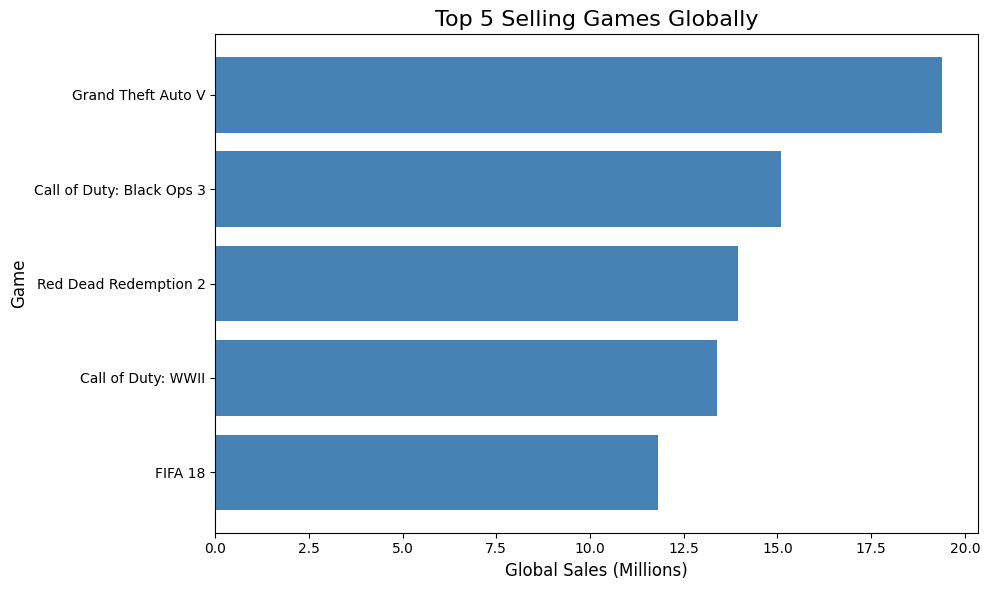

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(top_5_selling_global['Game'], top_5_selling_global['Global'], color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 5 Selling Games Globally', fontsize=16)
plt.xlabel('Global Sales (Millions)', fontsize=12)
plt.ylabel('Game', fontsize=12)
plt.tight_layout()
plt.show()

## Observation:

- Genre Diversity:
The top sellers span Action (GTA V), Shooter (Call of Duty titles), Action-Adventure (Red Dead Redemption 2), and Sports (FIFA 18) — showcasing a wide range of gamer interests.

- Publisher Influence:
Rockstar Games and Activision dominate the top ranks, highlighting their strong brand loyalty and marketing reach. EA Sports continues to be a global leader in sports games.

## Yearly trend with the highest number of game releases.

In [25]:
release_count_per_year = df['Year'].astype(int).value_counts().sort_index()
release_count_per_year

Year
2013     20
2014     98
2015    171
2016    427
2017    252
2018     39
2019     12
2020      8
Name: count, dtype: int64

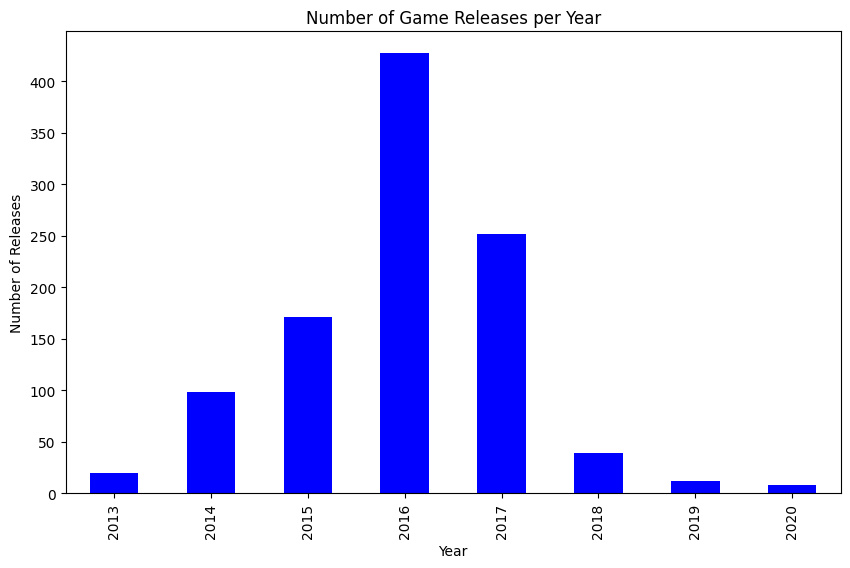

In [26]:
plt.figure(figsize=(10, 6))
release_count_per_year.plot(kind='bar', color='blue')
plt.title('Number of Game Releases per Year')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=90)
plt.show()

## Observation: 
### Yearly Trend in Number of Game Releases
- The number of game releases starts relatively low in 2013 with 20 titles.
- There is a sharp increase in releases, peaking dramatically in 2016 with 427 games released — the highest in the period.
- After 2016, the number of releases declines steadily:
    - Drops to 252 in 2017,
    - Then sharply falls to 39 in 2018,
    - And further declines to very low counts of 12 in 2019 and 8 in 2020.

This indicates 2016 was a peak year for game releases, possibly due to market dynamics, console cycles, or publisher strategies. The decline afterward could be due to industry consolidation, changes in consumer demand, or shifts toward fewer but higher-quality releases.



##	Compare the sales growth trend for "Action" and "Shooter" genres over the years.

In [27]:
df['Year'] = df['Year'].astype(int)

df_filtered = df[df['Genre'].isin(['Action', 'Shooter'])]
genre_sales_trends = df_filtered.groupby(['Year', 'Genre'])['Global'].sum().reset_index()
print(genre_sales_trends)

    Year    Genre  Global
0   2013   Action    1.91
1   2013  Shooter   11.13
2   2014   Action   31.97
3   2014  Shooter   21.38
4   2015   Action   29.73
5   2015  Shooter   36.95
6   2016   Action   25.92
7   2016  Shooter   29.80
8   2017   Action   30.51
9   2017  Shooter   30.92
10  2018   Action   16.81
11  2018  Shooter    0.27
12  2019   Action    0.00
13  2019  Shooter    0.00
14  2020   Action    0.00


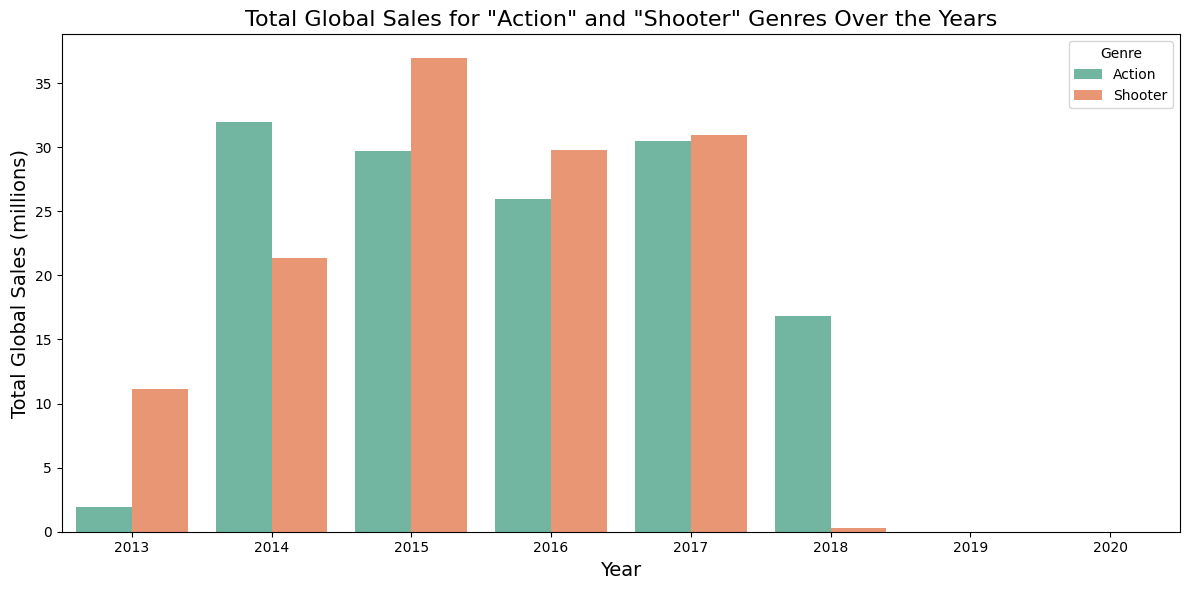

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(data=genre_sales_trends, x='Year', y='Global', hue='Genre', palette='Set2')

plt.title('Total Global Sales for "Action" and "Shooter" Genres Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Global Sales (millions)', fontsize=14)

plt.legend(title='Genre')
plt.tight_layout()

plt.show()

## Observation: 
Sales Growth Trend for Action vs Shooter Genres (2013–2020)

- #### Early Years (2013-2015):
    - Shooter genre dominates global sales with strong figures rising from 11.13M in 2013 to a peak of 36.95M in 2015.
    - Action games also show steady growth, increasing from 1.91M in 2013 to 31.97M in 2014 and slightly dipping to 29.73M in 2015.


- #### Mid Period (2016-2017):
    - Both genres maintain strong sales with Shooter sales slightly decreasing but staying robust around 29.8-30.9M.
    - Action sales stabilize around the low 30M range, showing consistent demand.


- #### Decline Phase (2018-2020):
    - Shooter genre sales sharply decline from 0.27M in 2018 to 0.00M by 2019, indicating possibly no significant new releases or a drop in market interest.
    - Action genre sales also drop dramatically to 16.81M in 2018 and reach 0.00M by 2019.



## Total sales comparison for regions (pie chart)

In [29]:
region_sales = df[['North America', 'Europe', 'Japan', 'Rest of World']].sum()

region_percentages = (region_sales / region_sales.sum()) * 100

print(region_percentages.round(2))


North America    33.92
Europe           44.33
Japan             5.94
Rest of World    15.81
dtype: float64


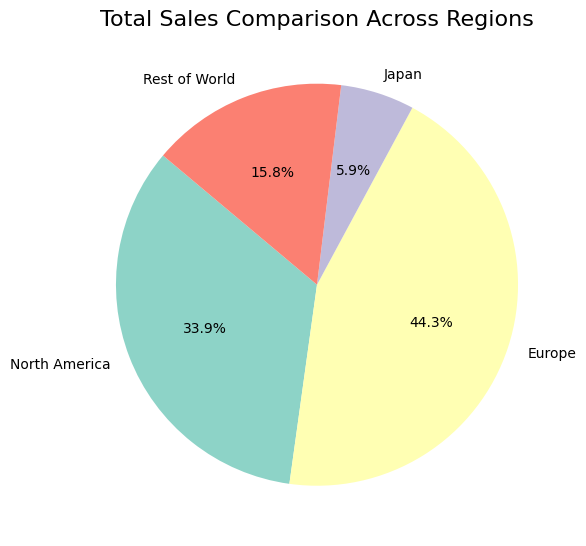

In [31]:
plt.figure(figsize=(6, 6))
plt.pie(region_sales, labels=region_sales.index, startangle=140, autopct='%1.1f%%', colors=plt.cm.Set3.colors)

plt.title('Total Sales Comparison Across Regions', fontsize=16)
plt.tight_layout()
plt.show()

## Observations

Europe leads game sales (44.33%), despite most top publishers being from Japan (e.g., Namco Bandai, Capcom) and North America (e.g., Sony, Activision).
Japan, though home to the most game publishers, has the lowest sales (5.94%), showing that Japanese games sell better globally than locally.
North America contributes significantly to both development and sales (33.92%), while the Rest of the World (15.81%) shows growth potential.

## Trend of global sales over the years (line chart)

In [32]:
global_sales_by_year = df.groupby('Year')['Global'].sum().reset_index()
global_sales_by_year

,Year,Global
0,2013,28.76
1,2014,115.85
2,2015,130.69
3,2016,131.40
4,2017,127.13
5,2018,50.20
6,2019,0.00
7,2020,0.00


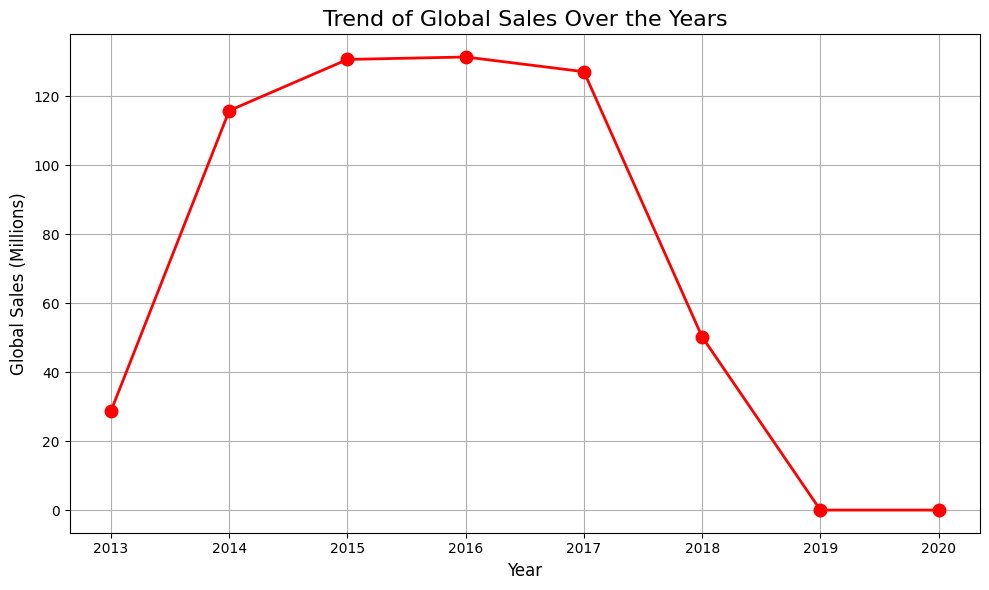

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(global_sales_by_year['Year'], global_sales_by_year['Global'], marker='o', color='r', linestyle='-', linewidth=2, markersize=9)
plt.title('Trend of Global Sales Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Global Sales (Millions)', fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

## Observations

- From 2013 to 2016, global game sales experienced a sharp and steady increase, reaching a peak of 131.40M in 2016.

- 2017 maintained high sales (127.13M), indicating strong sustained demand.

- A significant decline occurred in 2018, with global sales dropping to 50.20M.

- 2019 and 2020 show zero sales, which is likely due to covid 19 impact

## Contribution of each genre to regional sales (stacked bar chart).

In [34]:
genre_region_sales = df.groupby('Genre')[['North America', 'Europe', 'Japan', 'Rest of World']].sum()
genre_region_sales

,North America,Europe,Japan,Rest of World
Genre,,,,
Action,41.79,57.53,10.26,20.76
Action-Adventure,22.30,27.79,1.85,9.83
Adventure,5.27,6.08,1.64,2.23
Fighting,8.58,6.19,1.67,2.98
MMO,1.32,1.45,0.20,0.55
Misc,3.64,6.03,0.96,1.85
Music,2.40,1.62,0.17,0.84
Party,0.09,0.47,0.00,0.10
Platform,5.48,8.92,0.67,2.77


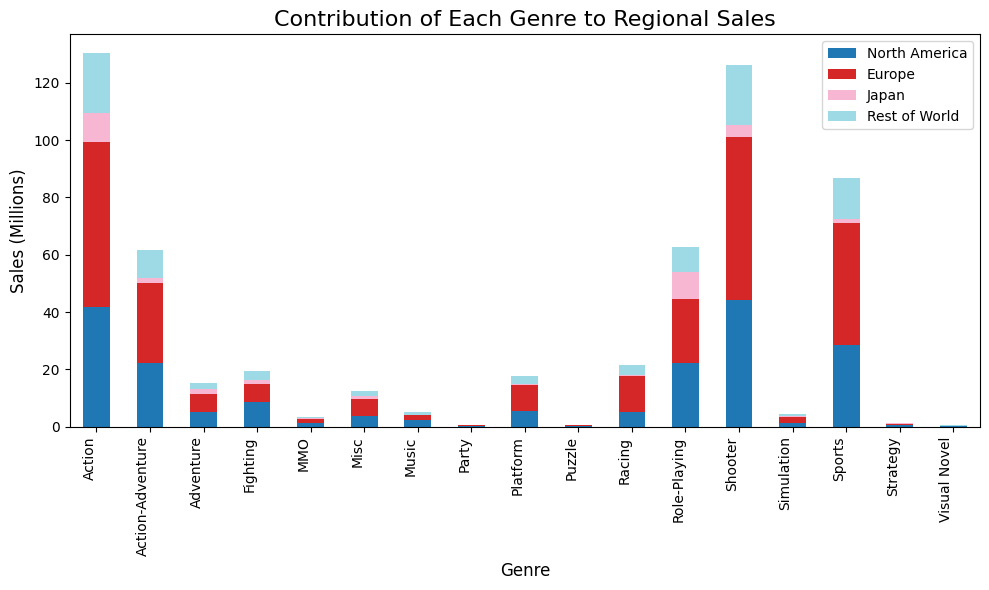

In [35]:
ax = genre_region_sales.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')

plt.title('Contribution of Each Genre to Regional Sales', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales (Millions)', fontsize=12)

plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

## Observations

- Action & Shooter dominate globally, leading in North America, Europe, and Rest of World.

- Sports genre thrives in Europe and North America, reflecting regional sports interest.

- Role-Playing is strongest in Japan, aligning with local gaming culture.

- Niche genres (e.g. Visual Novel, Puzzle) show minimal sales, mostly limited to Japan.

## Top 10 Publishers having most Game Releases

In [36]:
top_10_publishers = df['Publisher'].value_counts().head(10).reset_index()
top_10_publishers.columns = ['Publisher', 'Game Count']
top_10_publishers

,Publisher,Game Count
0,Namco Bandai Games,263
1,Sony Interactive Entertainment,46
2,Ubisoft,45
3,Square Enix,40
4,Tecmo Koei,37
5,Capcom,30
6,Activision,30
7,Warner Bros. Interactive Entertainment,27
8,Sony Computer Entertainment,25
9,Electronic Arts,21


## Compare Japan Vs Europe Sales Market (Combo chart)

In [37]:
df[df['Year'] == 2015]['Europe'].sum()

np.float64(55.9)

In [38]:
region_sales_by_year = df.groupby("Year")[["Japan", "Europe"]].sum()
region_sales_by_year

,Japan,Europe
Year,,
2013,0.81,12.88
2014,3.39,54.12
2015,7.14,55.90
2016,9.57,56.28
2017,8.84,54.83
2018,4.13,18.70
2019,0.00,0.00
2020,0.00,0.00


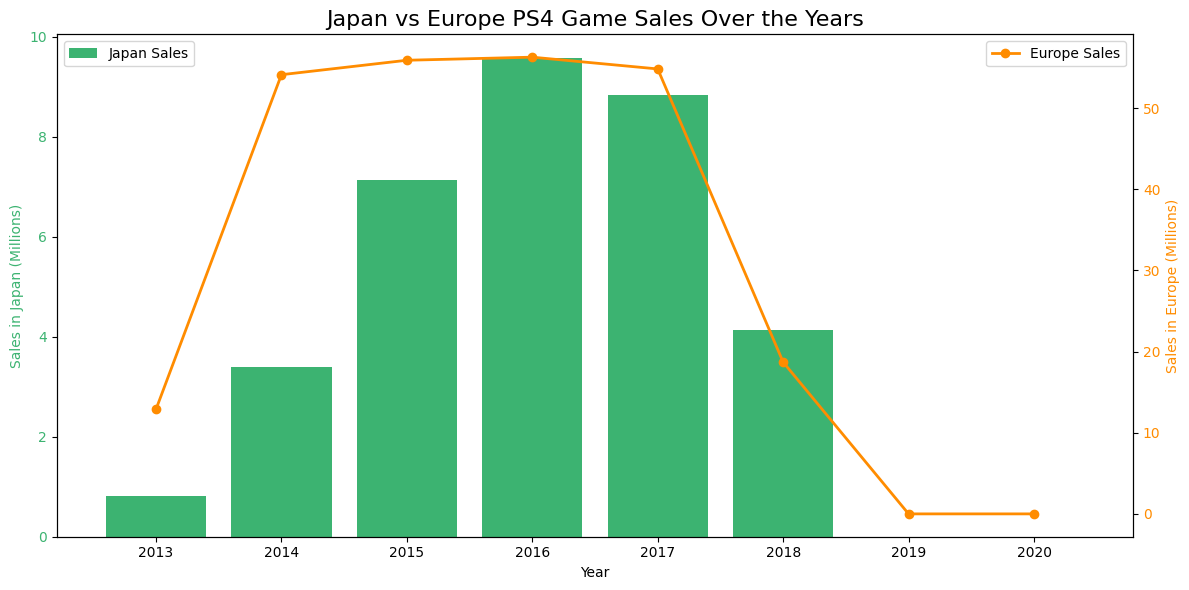

In [39]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(region_sales_by_year.index, region_sales_by_year["Japan"], color="mediumseagreen", label="Japan Sales")
ax1.set_xlabel("Year")
ax1.set_ylabel("Sales in Japan (Millions)", color="mediumseagreen")
ax1.tick_params(axis='y', labelcolor="mediumseagreen")

ax2 = ax1.twinx()
ax2.plot(region_sales_by_year.index, region_sales_by_year["Europe"], color="darkorange", marker="o", linewidth=2, label="Europe Sales")
ax2.set_ylabel("Sales in Europe (Millions)", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")

plt.title("Japan vs Europe PS4 Game Sales Over the Years", fontsize=16)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


## Observations

- Europe consistently outperforms Japan by a wide margin — often over 5x higher.

- Both markets peaked in 2016, with Europe at 56.28M and Japan at 9.57M.

- Japan shows a steady growth from 2013–2016, then a decline starting in 2018.

- Europe maintains high and stable sales through 2017, followed by a notable drop in 2018.

- 2019–2020 show no data, zero sales most probably impact of covid 19

## Show correlations by heatmap (positive and negative corr)

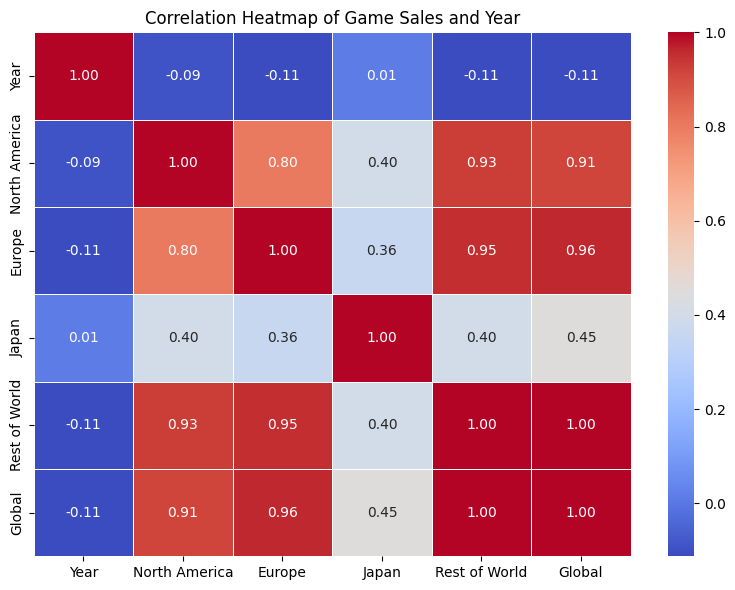

In [40]:
numeric_df = df[['Year', 'North America', 'Europe', 'Japan', 'Rest of World', 'Global']]

corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Game Sales and Year')
plt.tight_layout()
plt.show()

### Europe & Global: 0.963
Interpretation: European sales are also very closely tied to global sales.

Insight: Europe is likely one of the dominant markets influencing global sales.

### Year & Europe: -0.111

Interpretation: There's a slight negative correlation between release year and sales in Europe, North America, and Rest of World.

Insight: This could suggest that newer games in the dataset have slightly lower sales in those regions — possibly due to:
    
    - Shorter time on market (less cumulative sales)

    - Market saturation

    - Shift in regional gaming trends



## Conclusion (Summary)

- **Top Games & Publishers**:  
  *GTA V*, *Call of Duty* titles, *Red Dead Redemption 2*, and *FIFA 18* top the global sales chart, driven by **Rockstar Games**, **Activision**, and **EA Sports**.

- **Genre Trends**:  
  **Action** and **Shooter** games dominated from 2013–2017, with a steep drop in both genres post-2018.

- **Release Volume**:  
  2016 marked the **peak year** with **427 releases**; numbers declined sharply afterward, likely due to industry shifts and the **COVID-19 pandemic**.

- **Global Sales**:  
  Reached a peak in **2016 (131.40M)**, stayed high in 2017, then dropped significantly from 2018 onward. No sales data appeared in 2019–2020.

---

### Regional Sales Insights

- **Europe** leads with **44.33%** of total sales.  
- **North America** follows at **33.92%**.  
- **Rest of World** holds **15.81%**.  
- **Japan**, despite many publishers, accounts for just **5.94%**.

---

### Market-Specific Genre Preferences

- **Europe & NA**: Strong for *Action* and *Sports* genres.  
- **Japan**: Favors *Role-Playing*; niche genres (e.g., *Visual Novel*, *Puzzle*) remain localized.

---

### Japan vs Europe

- **Europe** outperforms **Japan** by **~5×**.  
- Both peaked in **2016** and declined sharply after **2018**.

---

### Correlation Insights

- **Europe & Global Sales**:  
  Strong positive correlation **(+0.963)** — Europe is a major influence on global sales trends.

- **Release Year vs Sales in Regions**:  
  Slight negative correlation **(-0.111)** — Newer games show lower sales, possibly due to:  
  - Shorter time on the market  
  - Market saturation  
  - Evolving regional gaming preferences
